# SHM catch in the act (v0)

## Notes:

- First dataset

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(fs)
library(stringr)
library(viridis)
library(ggpubr)
library(ggplot2)
#library("seqRFLP")
#library(ggExtra)
library(Seurat)
library(Biostrings) # this package interfer with dplyr
library(webr)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 20

In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
s_theme <- function() {
      t <- theme_classic() + theme(
        legend.position = "none",
        text = element_text(size = 15),
        axis.text.x = element_text(color = "black",size= 7),
        axis.text = element_text(size= 5),
        axis.title = element_text(size = 7), 
        legend.title = element_text(size = 7),legend.text=element_text(size=5),
        strip.text.x = element_text(size = 7),
        strip.background = element_blank(),
        plot.title = element_text(hjust = 0.5, size = 7)
      )
    
      return(t)
}

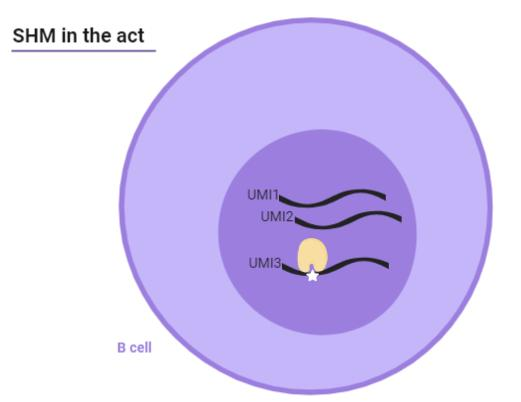

In [4]:
display_png(file="figs/shm-aid.jpeg")  

### Load input data (raw data)

- (!) Filter 0 We only consider cells with 100% coverage VDJ region

In [5]:
df_seq <- Sys.glob("input/output_shm_v4up/FL/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
      filter(ref_vdj_coverage == '1.0')
  })

In [6]:
head(df_seq)

cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACCTGAGTGTTTGC,AATTGACGCG,174,1.0,1.0,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
AAACCTGGTCCAGTAT,ACCTCGAATG,109,1.0,1.0,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGT

In [7]:
#read doublet table
dou_k123 <- read.csv("output/doublet_in_K123_v1.csv")

In [8]:
head(dou_k123)

,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,AAACCTGAGATCACGG,K1B,singlet,0.0066650216,3273,1471
2,AAACCTGAGCCAGTTT,K1B,singlet,0.0050010649,5993,1886
3,AAACCTGAGCGGCTTC,K1B,doublet,0.9994183779,6318,2544
4,AAACCTGAGGCATGTG,K1B,singlet,0.0687316433,3102,1317
5,AAACCTGAGTGTTTGC,K1B,singlet,0.0002979104,2582,1179
6,AAACCTGCAACTGCTA,K1B,singlet,0.0125339394,2894,1236


In [9]:
# number of doublet
table(dou_k123$scDblFinder.class)


doublet singlet 
   2791   25566 

In [10]:
# positive doublet table

dou_k123_pos <- dou_k123 %>% filter(scDblFinder.class == "doublet")
head(dou_k123_pos)

,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,AAACCTGAGCGGCTTC,K1B,doublet,0.9994184,6318,2544
2,AAACGGGCATTGGCGC,K1B,doublet,0.8618631,4679,1517
3,AAAGTAGTCAACGAAA,K1B,doublet,0.9996949,7281,2368
4,AAATGCCCAACTGGCC,K1B,doublet,0.9999716,13302,3548
5,AACACGTCACGTTGGC,K1B,doublet,0.8696232,7469,2629
6,AACCATGTCCGTTGCT,K1B,doublet,0.9995796,10143,3530


## 1. Filter Strategy

# Filtering steps
New filtering strategy UMI based.
1) Filter by quality of reads (@Diego)
2) VDJ coverage of 100%
3) Only VDJ region (Filter 1)
4) VDJ productive (Filter 1)

Unfiltered	253334
After F1	106935

5) only the biggest two alts: this filter do not make any difference
6) 

In [11]:
get_n_events <- function(df) {
  nrow(df %>% dplyr::count(subject, cell, position))
}

get_n_cells <- function(df) {  # we should use case because sometimes there are events in HC and LC of a same cell
  nrow(df %>% mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   dplyr::count(case, cell))
}


# load data
df <- Sys.glob("input/shm_incl_po_subrg.20210912/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

#save df without modification
dfo<- df

stats <- data.frame(step = c("Unfiltered"), n = c(get_n_events(df)), cell=c(get_n_cells(df)))


# f1. filter by doublet

## Include a variable expriment to can filter with the doublet table
df <- df %>% mutate(experiment = str_sub(subject, 1, 3))

df <- df %>% anti_join(dou_k123_pos, 
            by=c('cell','experiment'))

# filter values
c.region <- c("V","D","J")
c.min_depth <- 5
c.min_umis <- 10
c.min_2nd_ratio <- 0.2
c.max_cells_with_same_variation <- 1


stats <- stats %>%
  add_row(step = "After F1", n = get_n_events(df), cell=c(get_n_cells(df)))

In [12]:
# f2. primary filters (region + mindepth)
df <- df %>%
  dplyr::filter(region %in% c.region, productive == TRUE, depth >= c.min_depth) %>%
  dplyr::group_by(subject, cell, position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F2", n = get_n_events(df), cell=c(get_n_cells(df)))

In [13]:
# # f2.5 remove UMIs with "unique" profiles across the cell

# unique_umi_max_freq <- 1  # max number of UMIs associated with a profile to be considered unique
# unique_umis <- df %>%
#   mutate(event = paste0(position, ":", nucl)) %>%
#   group_by(experiment, cell, umi) %>%
#   summarise(profile = paste(event, collapse = ",")) %>%
#   group_by(experiment, cell, profile) %>%
#   mutate(n_times = n_distinct(umi)) %>%
#   filter(n_times <= unique_umi_max_freq) %>%
#   select(experiment, cell, umi)

# df <- df %>% anti_join(
#   unique_umis,
#   by = c("cell", "experiment", "umi")
# )

# stats <- stats %>%
#   add_row(step = "After F2.5", n = get_n_events(df), cell = c(get_n_cells(df)))

In [14]:

# f3. min_umis filter
min_umi_filter <- df %>%
  dplyr::count(subject, cell, position, nucl) %>%
  dplyr::filter(n >= c.min_umis) %>%
  dplyr::select(-n)

df <- df %>%
  dplyr::right_join(
    min_umi_filter,
    by = c("subject", "cell", "position", "nucl")
  ) %>%
  dplyr::group_by(subject, cell, vgene_position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F3", n = get_n_events(df), cell=c(get_n_cells(df)))

In [15]:
# # f3. keep only the biggest two alts
# two_alts_filter <- df %>%
#   dplyr::group_by(subject, cell, position, nucl) %>%
#   summarize(n = n()) %>%
#    dplyr::slice_max(n, n = 2)%>%
#   dplyr::select(subject, cell, position, nucl)

# df <- df %>%
#   dplyr::right_join(two_alts_filter, by = c("subject", "cell", "position", "nucl"))

# stats <- stats %>%
#   add_row(step = "After F2", n = get_n_events(df), cell=c(get_n_cells(df)))

In [16]:
# f4. min_ratio filter
min_ratio_filter <- df %>%
  dplyr::count(subject, cell, position, nucl) %>%
  dplyr::group_by(subject, cell, position) %>%
  dplyr::mutate(ratio = n / sum(n)) %>%
  dplyr::arrange(subject, cell, position, desc(ratio)) %>%
  dplyr::slice(2) %>%
  dplyr::filter(ratio >= c.min_2nd_ratio) %>%
  dplyr::select(subject, cell, position)

df <- df %>%
  dplyr::right_join(
    min_ratio_filter,
    by = c("subject", "cell", "position")
  ) %>%
  dplyr::group_by(subject, cell, vgene_position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F4", n = get_n_events(df), cell=c(get_n_cells(df)))

In [18]:
# summarize
df_productive <- df %>%
  dplyr::select(subject, cell, vgene_position_aligned, productive,subregion) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell, vgene_position_aligned,subregion) %>%
  dplyr::summarise(productive = paste(productive, collapse = "-")) %>%
  dplyr::mutate(productive = ifelse(grepl("-", productive), "MIXED", productive))

#Save umis for ploting
df_umis_f4 <- df

df_summary <- df %>%
  dplyr::group_by(subject, cell, vgene_position_aligned, nucl, nucl_po, context_po,subregion) %>%
  dplyr::summarise(umis = n()) %>%
  dplyr::group_by(subject, cell, vgene_position_aligned, nucl_po, context_po,subregion) %>%
  dplyr::arrange(nucl) %>%
  dplyr::summarise(
    variation = paste(nucl, collapse = "-"),
    umis = paste(umis, collapse = "-")
  ) %>%
  dplyr::ungroup() %>%
  left_join(df_productive)

Adding missing grouping variables: `vgene_position`
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned', 'nucl', 'nucl_po', 'context_po'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned', 'nucl_po', 'context_po'. You can override using the `.groups` argument.
Joining with `by = join_by(subject, cell, vgene_position_aligned, subregion)`


In [19]:
# f5. discard cells with the same mutational profile
cells_same_var_filter <- df_summary %>%
  dplyr::mutate(variation_wpos = paste(vgene_position_aligned, variation, sep=":")) %>%
  dplyr::select(subject, cell, variation_wpos) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell) %>%
  dplyr::summarise(profile=paste0(variation_wpos, collapse = ",")) %>%
  dplyr::group_by(subject, profile) %>%
  dplyr::mutate(cell_same_profile=n_distinct(cell)) %>%
  dplyr::filter(cell_same_profile > 1) %>%
  dplyr::select(subject, cell)

df_summary <- df_summary %>%
  dplyr::anti_join(cells_same_var_filter, by = c("subject", "cell")) %>%
  dplyr::arrange(subject, vgene_position_aligned, variation) %>%
  as.data.frame()

stats <- stats %>%
  add_row(step = "After F5", n = nrow(df_summary), cell=c(get_n_cells(df_summary)))

stats

# summary by subject
df_summary_by_subject <- df_summary %>%
  dplyr::count(subject)

`summarise()` has grouped output by 'subject'. You can override using the `.groups` argument.
Adding missing grouping variables: `profile`


step,n,cell
<chr>,<int>,<int>
Unfiltered,81724,13543
After F1,70921,12326
After F2,4994,2995
After F3,185,74
After F4,145,61
After F5,139,55


In [20]:
write.csv(df_summary, "output/df_summary_K123_v3.csv",row.names = FALSE)

In [21]:
# write umis by cell fir ploting
df_umis <- df_umis_f4 %>% filter(cell %in% df_summary$cell) 
write.csv(df_umis, "output/df_umis_K123.csv",row.names = FALSE)

## 2. Downstream analysis

### A) How many events by subject?

In [21]:
df_summary_by_subject <- df_summary %>% mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case,gene)

df_summary_by_subject

case,gene,n
<chr>,<chr>,<int>
K1B_S10000,LC,4
K1B_S144,HC,3
K1B_S144,LC,112
K1B_S8934,LC,1
K2B_S11770,LC,3
K2B_S12118,HC,1
K2B_S12500,HC,1
K2B_S12500,LC,1
K2B_S13530,LC,2


In [22]:
print("Number of events")
sum(df_summary_by_subject$n)

[1] "Number of events"


[1] 153

In [23]:
df_summary_by_case<- df_summary %>% mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case) %>%
  dplyr::rename(Total_events=n)

print("Number of TOTAL events by case")
df_summary_by_case

[1] "Number of TOTAL events by case"


case,Total_events
<chr>,<int>
K1B_S10000,4
K1B_S144,115
K1B_S8934,1
K2B_S11770,3
K2B_S12118,1
K2B_S12500,2
K2B_S13530,2
K2B_S13553,21
K3B_S8934,4


### B) How many cells have SHMacting by subject?

### Amount of cell by case with SHMxx

In [24]:
shm_cell_case <- df_summary %>% 
   mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   summarise(scSHM_cell = n_distinct(cell))

In [25]:
shm_cell_case

case,scSHM_cell
<chr>,<int>
K1B_S10000,4
K1B_S144,56
K1B_S8934,1
K2B_S11770,1
K2B_S12118,1
K2B_S12500,1
K2B_S13530,2
K2B_S13553,15
K3B_S8934,1


In [26]:
unique(df_seq$subject)

[1] "K1B_S10000-HC" "K1B_S10000-LC" "K1B_S10971-HC" "K1B_S10971-LC"
 [5] "K1B_S12282-HC" "K1B_S12282-LC" "K1B_S144-HC"   "K1B_S144-LC"  
 [9] "K1B_S8934-HC"  "K1B_S8934-LC"  "K2B_S11770-HC" "K2B_S11770-LC"
[13] "K2B_S12118-HC" "K2B_S12118-LC" "K2B_S12500-HC" "K2B_S12500-LC"
[17] "K2B_S13530-HC" "K2B_S13530-LC" "K2B_S13553-HC" "K2B_S13553-LC"
[21] "K3B_S12390-HC" "K3B_S12390-LC" "K3B_S12500-HC" "K3B_S12500-LC"
[25] "K3B_S8382-HC"  "K3B_S8382-LC"  "K3B_S8934-HC"  "K3B_S8934-LC"

In [27]:
case_cell <- df_seq %>% 
   mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   summarise(total_cell = n_distinct(cell)) %>%
   left_join(shm_cell_case, by='case') %>%
   replace(is.na(.), 0) %>%
   mutate(Percentage =scSHM_cell * 100 / total_cell)
case_cell

case,total_cell,scSHM_cell,Percentage
<chr>,<int>,<int>,<dbl>
K1B_S10000,1614,4,0.24783147
K1B_S10971,1089,0,0.00000000
K1B_S12282,400,0,0.00000000
K1B_S144,1489,56,3.76091336
K1B_S8934,1646,1,0.06075334
K2B_S11770,215,1,0.46511628
K2B_S12118,848,1,0.11792453
K2B_S12500,1465,1,0.06825939
K2B_S13530,1985,2,0.10075567


In [28]:
# Total number of cells

print("Number of TOTAL cells with events")
case_cell %>% pull(scSHM_cell) %>% sum()

[1] "Number of TOTAL cells with events"


[1] 82

### C) How many positions have SHMacting by subject?"

In [29]:
c_pos <-df_summary %>%
  mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  group_by(case,gene) %>%
  summarise(n_pos = n_distinct(vgene_position_aligned))

c_pos

`summarise()` has grouped output by 'case'. You can override using the `.groups` argument.


case,gene,n_pos
<chr>,<chr>,<int>
K1B_S10000,LC,4
K1B_S144,HC,3
K1B_S144,LC,91
K1B_S8934,LC,1
K2B_S11770,LC,3
K2B_S12118,HC,1
K2B_S12500,HC,1
K2B_S12500,LC,1
K2B_S13530,LC,2


### Master table

In [30]:
summary <- df_summary_by_subject %>% 
          right_join(df_summary_by_case, by = "case") %>%
          right_join(case_cell, by = "case") %>%
#           left_join(c_pos, by = c("case", "gene")) %>%
           dplyr::rename(Patient=case) %>%
#           select(-subject) %>%
           pivot_wider(names_from="gene", values_from="n") %>%
           select(Patient,total_cell,scSHM_cell,Percentage,Total_events,everything()) %>% #, -`NA`
           replace(is.na(.), 0) %>%
           dplyr::rename(event_HC=HC, event_LC=LC)

write.csv(summary, "output/summary_FL_K123.csv")
summary

Patient,total_cell,scSHM_cell,Percentage,Total_events,event_LC,event_HC,NA
<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>
K1B_S10000,1614,4,0.24783147,4,4,0,0
K1B_S144,1489,56,3.76091336,115,112,3,0
K1B_S8934,1646,1,0.06075334,1,1,0,0
K2B_S11770,215,1,0.46511628,3,3,0,0
K2B_S12118,848,1,0.11792453,1,0,1,0
K2B_S12500,1465,1,0.06825939,2,1,1,0
K2B_S13530,1985,2,0.10075567,2,2,0,0
K2B_S13553,1005,15,1.49253731,21,21,0,0
K3B_S8934,1331,1,0.07513148,4,4,0,0


### D) Number of event (positions) by cell

In [31]:
#pos by cell
pbc <- df_summary %>% #filter(source == "K2B_S12500_L")
   group_by(subject, cell) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) %>%
   mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)"))
head(pbc)

`summarise()` has grouped output by 'subject'. You can override using the `.groups` argument.


subject,cell,pos_by_cell,case
<chr>,<chr>,<int>,<chr>
K1B_S10000-LC,ACTTTCACATTGTGCA,1,S10000
K1B_S10000-LC,CGAGCACAGGTTCCTA,1,S10000
K1B_S10000-LC,CTAGCCTCAATCACAC,1,S10000
K1B_S10000-LC,TTAGGCAGTCGAACAG,1,S10000
K1B_S144-HC,CTCGAGGCAATGACCT,1,S144
K1B_S144-HC,GTCACAACAACGATCT,2,S144


In [32]:
## 3. Visualizations

# # prepare df foe new plots
# df_filter_vis <- df_summary %>% 
#             separate(variation, c("variation1", "variation2"), "-",remove = FALSE) %>%
#             separate(umis, c("umis1", "umis2"), "-",remove = FALSE, convert= TRUE)%>%
#             mutate(umis2 = umis2 * -1) %>%
#             gather('umis1', 'umis2',key='umi_nu',value="umi") %>%
#             mutate(nucleotide = if_else(umi_nu == "umis1", variation1,variation2)) %>%
#             mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
#             group_by(case) %>%
#             mutate(cell_no = paste0("Cell ",as.integer(factor(cell)))) #%>%
# #            left_join(df %>% select(cell,vgene_position_aligned,subject,context), by=c('cell','vgene_position_aligned','subject'))
# #            gather('variation1', 'variation2',key='variation_type',value="nucleotide")

## Overview

In [33]:
#read expression summary data
shm_perc_sub <- read.csv("output/expresion_data_perc_sub_K45678_cat.csv")

In [34]:
head(shm_perc_sub)

,subject,gene,group,expression,count,perc,pathway
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
1,S10000,ADAR,SHMss_observed,No,37,42.04545,RNSA_editing
2,S10000,ADAR,SHMss_observed,Yes,51,57.95455,RNSA_editing
3,S10000,ADAR,SHMss_not_observed,No,56,72.72727,RNSA_editing
4,S10000,ADAR,SHMss_not_observed,Yes,21,27.27273,RNSA_editing
5,S10000,AICDA,SHMss_observed,No,45,51.13636,SHM
6,S10000,AICDA,SHMss_observed,Yes,43,48.86364,SHM


In [35]:
shm_perc_sub_aid <- shm_perc_sub %>%
                    filter(gene == "AICDA") %>%
                    select(-pathway,-gene) %>%
                    pivot_wider(names_from=c(expression,group), 
                    values_from=c(count, perc)) %>%
                    replace(is.na(.), 0)

#### Overview full SHM + total by case + expression AID

In [36]:
# vector to renames columns
old_names = c("count_No_SHMss_observed","count_No_SHMss_not_observed","count_Yes_SHMss_not_observed","count_Yes_SHMss_observed",
              "perc_No_SHMss_observed","perc_No_SHMss_not_observed","perc_Yes_SHMss_not_observed","perc_Yes_SHMss_observed")
new_names = c("AID_neg_SHM_obs.cells","AID_neg_SHM_not_obs.cells","AID_pos_SHM_not_obs.cells", "AID_pos_SHM_obs.cells",
              "perc.AID_neg_SHMss_observed", "perc.AID_neg_SHM_not_obs.cells", "perc.AID_pos_SHM_not_obs.cells","perc.AID_pos_SHM_obs.cells")
overview <- summary %>% 
            mutate(Patient_id =str_extract(Patient, "(?<=_).*")) %>% 
#            left_join(case_cell, c("Patient"="case")) #%>%
            left_join(shm_perc_sub_aid, c("Patient_id"="subject") ) %>% #%>% rename(Percentage_w_wo_AID=Percentage,AID_group=group,Nu.cell_w_wo_AID=counts),"subject"
           mutate(diagnosis="FL",.after = Patient) %>%
            rename_at(all_of(old_names), ~ new_names) #%>%
#            select(-type,-case) %>%
#            relocate(group, .before = total_cell)
          
       
write.csv(overview, "output/overview_FL_full.csv",row.names = FALSE) 
overview

Patient,diagnosis,total_cell,scSHM_cell,Percentage,Total_events,event_LC,event_HC,NA,Patient_id,AID_neg_SHM_obs.cells,AID_pos_SHM_obs.cells,AID_neg_SHM_not_obs.cells,AID_pos_SHM_not_obs.cells,perc.AID_neg_SHMss_observed,perc.AID_pos_SHM_obs.cells,perc.AID_neg_SHM_not_obs.cells,perc.AID_pos_SHM_not_obs.cells
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
K1B_S10000,FL,1614,4,0.24783147,4,4,0,0,S10000,45,43,69,8,51.13636,48.863636,89.61039,10.389610
K1B_S144,FL,1489,56,3.76091336,115,112,3,0,S144,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S8934,FL,1646,1,0.06075334,1,1,0,0,S8934,9,2,4947,311,81.81818,18.181818,94.08520,5.914797
K2B_S11770,FL,215,1,0.46511628,3,3,0,0,S11770,NA,NA,NA,NA,NA,NA,NA,NA
K2B_S12118,FL,848,1,0.11792453,1,0,1,0,S12118,NA,NA,NA,NA,NA,NA,NA,NA
K2B_S12500,FL,1465,1,0.06825939,2,1,1,0,S12500,NA,NA,NA,NA,NA,NA,NA,NA
K2B_S13530,FL,1985,2,0.10075567,2,2,0,0,S13530,24,21,15,1,53.33333,46.666667,93.75000,6.250000
K2B_S13553,FL,1005,15,1.49253731,21,21,0,0,S13553,70,7,513,38,90.90909,9.090909,93.10345,6.896552
K3B_S8934,FL,1331,1,0.07513148,4,4,0,0,S8934,9,2,4947,311,81.81818,18.181818,94.08520,5.914797


## Include AID motifs

In [37]:
# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

In [38]:
identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [39]:
df_summary$aid_motif1 <- mapply(identify_aid_patterns, df_summary$variation, df_summary$context_po)
df_summary$aid_motif2 <- mapply(identify_aid_patterns, reverse(df_summary$variation), df_summary$context_po)

In [40]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [41]:
AID_motif_summ <-df_summary %>%  group_by(aid_motif1) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% mutate(AID=c("No","Yes","Yes","Yes")) %>%
                 rename("aid_motif1"="Motifs")
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,85,55.555556,No
RCG,3,1.960784,Yes
WA,46,30.065359,Yes
WRCY,19,12.418301,Yes


In [42]:
print('% AID-related motifs in SHMss FL')
(AID_motif_summ$Percentage[2] + AID_motif_summ$Percentage[3] + AID_motif_summ$Percentage[4])

[1] "% AID-related motifs in SHMss FL"


[1] 44.44444

### Pie plot AID motif

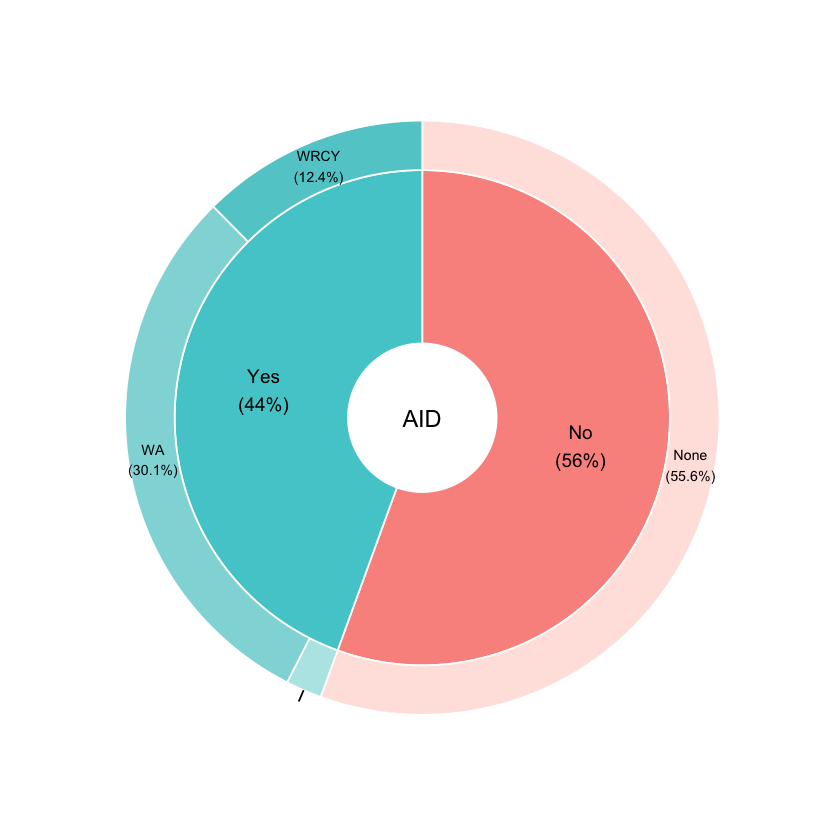

In [46]:
#pdf("figs/pie_AID.pdf") # width = 600, height=350

# Pie-Donut chart
pie_querico <- PieDonut(AID_motif_summ, aes(AID,Motifs, count=Percentage), ratioByGroup = FALSE)
#dev.off()

#fig_save(pie_querico , filename = ("figs/pie_AID"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

### Compare CLL and FL (delete only for presentation purpose)

In [47]:
diagnosis <- c("FL", "FL", "CLL","CLL")
SHM_ongoing <- c("Positive", "Negative", "Positive", "Negative")
n <- c(12,7,0,5)

FL_CLL <- data.frame(diagnosis, SHM_ongoing,n) %>% group_by(diagnosis) %>% mutate(Percentage= n * 100 / sum(n)) %>%
        dplyr::mutate(diagnosis = factor(diagnosis,
                                     levels = c("FL","CLL"))) %>%
                dplyr::mutate(SHM_ongoing = factor(SHM_ongoing,
                                     levels = c("Positive","Negative")))
FL_CLL 

diagnosis,SHM_ongoing,n,Percentage
<fct>,<fct>,<dbl>,<dbl>
FL,Positive,12,63.15789
FL,Negative,7,36.84211
CLL,Positive,0,0.00000
CLL,Negative,5,100.00000


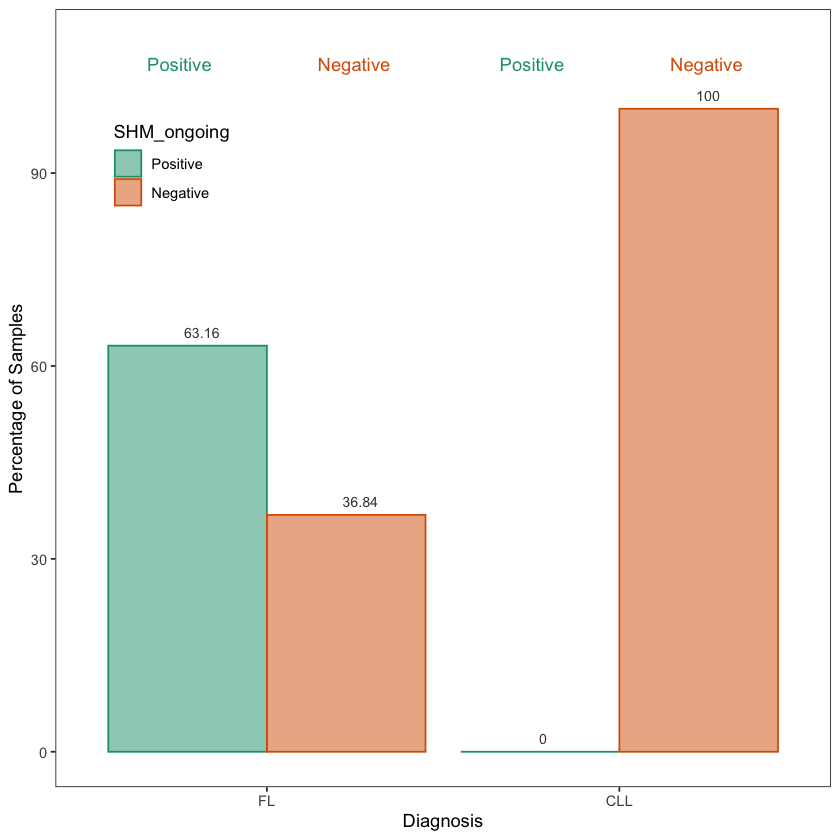

In [48]:
# coloured barplot
shM_ong <- ggplot(FL_CLL, aes(x = diagnosis, y = Percentage, fill = SHM_ongoing, colour = SHM_ongoing)) + 
  geom_bar(stat = "identity", position = "dodge", alpha = 0.5)  +
  labs(x="Diagnosis", y="Percentage of Samples") +
  theme_bw() + 
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank()) +
  theme(legend.position = c(0.15, 0.8)) +
  geom_text(aes(label=round(Percentage,2)), position = position_dodge(0.90), size = 3, 
            vjust=-0.8, hjust=0.1, colour = "gray25") +
  ylim(0, 110) +
  geom_text(aes(label=SHM_ongoing, y = 107), position = position_dodge(0.99), show.legend = FALSE) +
  scale_fill_brewer(palette = "Dark2") +
  scale_color_brewer(palette = "Dark2")

shM_ong

fig_save(shM_ong , filename = ("figs/SHM_ongoing"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

## Add clonotype data

In [49]:
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesMulti_AllCellsForJulieta2023_02_22.csv") 

In [50]:
head(clonotype) 

,barcode,contigId,chain,v_gene,j_gene,c_gene,is_cell,high_confidence,full_length,productive,⋯,seqLen,seqFull,seqFullLen,seqAa,NliGsingleChain,NliG,contigs,genes,vGeneIMGT,cell
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,CAAGTTGTCTTGCAAG-1,CAAGTTGTCTTGCAAG-1_contig_1,IGK,IGKV3-20,IGKJ2,IGKC,TRUE,TRUE,TRUE,TRUE,⋯,325,acatggggagagctctgcagaagagctgctcagttaggacccagagggaaccatggaaaccccagcgcagcttctcttcctcctgctactctggctcccaggaaacatcggagagattgtcttgacgcagtctccaggcgtcttgtctttctctcttggggacagagtcagcctctcctgcagggccagtcaaattatcaacacagtttctttggcctggtatcaacagagacgtggccagcctcccagactcctcatctatggtgcgtcgacgagggccactggcatcccagacaggttcagtggcagtgggtctgcgacagacttcagtctcatcatcagcagtctggagcctgaagattttggagtttattactgtcaccactatggaacctcacccgacacttttggccaggggaccaaattggagatcaaacgaactgtggctgcaccatctgtcttcatcttcccgccatctgatgagcagttgaaatctggaactgcctctgttgtgtgcctgctgaataacttctatcccagagaggccaaagtacagtggaaggtggataacgc,573,EIVLTQSPGVLSFSLGDRVSLSCRASQIINTVSLAWYQQRRGQPPRLLIYGASTRATGIPDRFSGSGSATDFSLIISSLEPEDFGVYYCHHYGTSPDTFGQGTKLEIK,0,0,1,K,IGKV3-20,K1B:CAAGTTGTCTTGCAAG-1
2,CAGCGACCACCGCTAG-1,CAGCGACCACCGCTAG-1_contig_2,IGK,IGKV3-20,IGKJ2,IGKC,FALSE,FALSE,TRUE,TRUE,⋯,325,ggagaagagctgctcagttaggacccagagggaaccatggaaaccccagcgcagcttctcttcctcctgctactctggctcccaggaaacatcggagagattgtcttgacgcagtctccaggcgtcttgtctttctctcttggggacagagtcagcctctcctgcagggccagtcaaattatcaacacagtttctttggcctggtatcaacagagacctggccagcctcccagactcctcatctatggtgcgtcgacgagggccactggcatcccagacaggttcagtggcagtgggtctgcgacagacttcagtctcatcatcagcagtctggagcctgaagattttggagtttattactgtcaccactatggaacctcacccgacacttttggccaggggaccaaattggagatcaaacgaactgtggctgcaccatctgtcttcatcttcccgccatctgatgagcagttgaaatctggaactgcctctgttgtgtgcctgctgaataacttctatcccagagaggccaaagtacagtggaaggtggataacgc,557,EIVLTQSPGVLSFSLGDRVSLSCRASQIINTVSLAWYQQRPGQPPRLLIYGASTRATGIPDRFSGSGSATDFSLIISSLEPEDFGVYYCHHYGTSPDTFGQGTKLEIK,0,0,1,K,IGKV3-20,K1B:CAGCGACCACCGCTAG-1
3,CATCAGATCACTTCAT-1,CATCAGATCACTTCAT-1_contig_1,IGK,IGKV3-20,IGKJ2,IGKC,TRUE,TRUE,TRUE,TRUE,⋯,325,ggcagctgcaagcccagcacccgccccagctgctttgcatgtccctcccagccgccctgcagtccagagcccaaatcaatgcctgggtcagagctctgcagaagagctgctcagttaggacccagagggaaccatggaaaccccagcgcagcttctcttcctcctgctactctggctcccaggaaacatcggagagattgtcttgacgcagtctccaggcgtcttgtctttctctcttggggacagagtcagcctctcctgcagggccagtcaaattatcaacacagtttctttggcctggtatcaacagagacctggccagcctcccagactcctcatctatggtgcgtcgacgagggccactggcatcccagacaggttcagtggcagtgggtctgcgacagacttcagtctcatcatcagcagtctggagcctgaagattttggagtttattactgtcaccactatggaacctcacccgacacttttggccaggggaccaaattggagatcaaacgaactgtggctgcaccatctgtcttcatcttcccgccatctgatgagcagttgaaatctggaactgcctctgttgtgtgcctgctgaataacttctatcccagagaggccaaagtacagtggaaggtggataacgc,654,EIVLTQSPGVLSFSLGDRVSLSCRASQIINTVSLAWYQQRPGQPPRLLIYGASTRATGIPDRFSGSGSATDFSLIISSLEPEDFGVYYCHHYGTSPDTFGQGTKLEIK,0,0,1,K,IGKV3-20,K1B:CATCAGATCACTTCAT-1
4,CGATTGATCCGTCAAA-1,CGATTGATCCGTCAAA-1_contig_1,IGK,IGKV3-20,IGKJ2,IGKC,TRUE,TRUE,TRUE,TRUE,⋯,325,cccagctgctttgcatgtccctcccagccgccctgcagtccagagcccaaatcaatgcctgggtcagagctctgcagaagagctgctcagttaggacccagagggaaccatggaaaccccagcgcagcttctcttcctcctgctactctggctcccaggaaacatcggagagattgtcttgacgcagtctccaggcgtcttgtctttctctcttggggacagagtcagcctctcctgcagggccagtcaaattatcaacacagtttctttggcctggtatcaacagagacctggccagcctcccagactcctcatctatggtgcgtcgacgagggccactggcatcccagacaggttcagtggcagtgggtctgcgacagacttcagtctcatcatcagcagtctggagcctgaagattttggagtttattactgtcaccactatggaacctcacccgacacttttggccaggggaccaaattggagatcaaacgaactgtggctgcaccatctgtcttcatcttcccgccatctgatgagcagttgaaatctggaactgcctctgttgtgtgcctgctgaataacttctatcccagagaggccaaagtacagtggaaggtggataacgc,630,EIVLTQSPGVLSFSLGDRVSLSCRASQIINTVSLAWYQQRPGQPPRLLIYGASTRATGIPDRFSGSGSATDFSLIISSLEPEDFGVYYCHHYGTSPDTFGQGTKLEIK,0,0,1,K,IGKV3-20,K1B:CGATTGATCCGTCAAA-1
5,CTAGAGTTCGACCAGC-1,CTAGAGTTCGACCAGC-1_contig_1,IGK,IGKV3-20,IGKJ2,IGKC,TRUE,TRUE,TRUE,TRUE,⋯,325,ggagaagagctgctcagttaggacccagagggaaccatggaaaccccagcgcagcttctcttcctcctgctactctggctcccaggaaacatcggagagattgtcttgacgcagtctccaggcgtcttgtctttctctcttggggacagagtcagcctctcctgcagggccagt

In [51]:
# raw version from seurat
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesMulti_AllCellsForJulieta2023_02_22.csv") %>% mutate(source=str_extract(cell, "^.{3}"),cell = gsub(".{2}$", "", barcode)) %>% 
             select(source,cell,chain,is_cell,productive,high_confidence,umis,reads,NliGsingleChain,NliG)  %>% 
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                     chain == "IGK" | chain == "IGL" ~ "LC",
                                    TRUE ~ "NA"))

In [52]:
#add clonotype data (fist add gene column in df summary for joining)
#df_summary_clonotype <- df_summary %>% mutate(gene=if_else(str_sub(subject, -2) == "HC", "HC", "LC")) %>% left_join(clonotype, c("cell","gene"))
df_summary_clonotype <- df_summary %>% mutate(gene=if_else(str_sub(subject, -2) == "HC", "HC", "LC"),
                                              source=str_sub(subject, 1, 3)) %>%  
                                              left_join(clonotype, c("cell","gene","source"))

In [53]:
table(clonotype$NliG)


   0    1    2    3    4    5    6    7    8    9   11 
4807 7986 7324 4045 4883 1351  110    3   36    7    4 

In [54]:
table(df_summary_clonotype$NliGsingleChain)


  0   1   2   3   4 
149  16  13  13   1 

In [55]:
df_summary_clonotype %>% filter(is.na(NliGsingleChain))

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,gene,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,NliGsingleChain,NliG
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>


In [56]:
df_summary %>% filter(subject == "K1B_S144-LC")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,aid_motif1,aid_motif2
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K1B_S144-LC,TTTCCTCCACTTAAGC,4,A,AC.TC,FR1,A-G,6-7,TRUE,None,RCG
K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-23,TRUE,None,WA
K1B_S144-LC,TTTCCTCCACTTAAGC,8,A,CC.GA,FR1,A-G,6-7,TRUE,None,None
K1B_S144-LC,TTTCCTCCACTTAAGC,10,A,AG.TG,FR1,A-G,6-7,TRUE,None,None
K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE,WA,None
K1B_S144-LC,ATGAGGGGTGTATGGG,24,A,CC.TC,FR1,A-T,5-15,TRUE,None,WA
K1B_S144-LC,ACGCCAGAGGCATTGG,25,T,CA.CC,FR1,C-T,14-17,TRUE,None,None
K1B_S144-LC,GTCACAACAACGATCT,27,C,TC.TC,FR1,C-G,16-7,TRUE,None,RCG
K1B_S144-LC,CACATAGTCATACGGT,29,C,CT.CC,FR1,C-T,70-36,TRUE,None,None


In [57]:
df_summary_clonotype %>% filter(subject == "K1B_S144-LC") %>% head(.,-10)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,gene,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,NliGsingleChain,NliG
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>
1,K1B_S144-LC,TTTCCTCCACTTAAGC,4,A,AC.TC,FR1,A-G,6-7,TRUE,None,⋯,LC,K1B,IGK,TRUE,TRUE,TRUE,16,2858,0,1
2,K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-23,TRUE,None,⋯,LC,K1B,IGK,TRUE,TRUE,TRUE,38,7916,0,1
3,K1B_S144-LC,TTTCCTCCACTTAAGC,8,A,CC.GA,FR1,A-G,6-7,TRUE,None,⋯,LC,K1B,IGK,TRUE,TRUE,TRUE,16,2858,0,1
4,K1B_S144-LC,TTTCCTCCACTTAAGC,10,A,AG.TG,FR1,A-G,6-7,TRUE,None,⋯,LC,K1B,IGK,TRUE,TRUE,TRUE,16,2858,0,1
5,K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE,WA,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,20,4078,0,1
6,K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE,WA,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,32,6350,0,1
7,K1B_S144-LC,ATGAGGGGTGTATGGG,24,A,CC.TC,FR1,A-T,5-15,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,17,3432,0,1
8,K1B_S144-LC,ATGAGGGGTGTATGGG,24,A,CC.TC,FR1,A-T,5-15,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,10,1424,0,1
9,K1B_S144-LC,ACGCCAGAGGCATTGG,25,T,CA.CC,FR1,C-T,14-17,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,19,3914,0,1


In [59]:
df_summary_clonotype %>% filter(subject == "K1B_S144-LC", cell %in% df_summary) %>% count(NliG)

NliG,n
<int>,<int>


In [63]:
df_summary_clonotype %>% group_by(subject,gene) %>% count(NliG)
#df_summary_clonotype %>% group_by(subject,gene) %>% count(NliGsingleChain)

subject,gene,NliG,n
<chr>,<chr>,<int>,<int>
K1B_S10000-LC,LC,2,2
K1B_S10000-LC,LC,3,2
K1B_S144-HC,HC,1,3
K1B_S144-LC,LC,0,15
K1B_S144-LC,LC,1,125
K1B_S144-LC,LC,2,8
K1B_S8934-LC,LC,4,1
K2B_S11770-LC,LC,1,3
K2B_S12118-HC,HC,3,1


In [65]:
df_summary_clonotype %>% filter(is_cell == "FALSE")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,gene,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,NliGsingleChain,NliG
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>
K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE,WA,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,20,4078,0,1
K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE,WA,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,32,6350,0,1
K1B_S144-LC,ATGAGGGGTGTATGGG,24,A,CC.TC,FR1,A-T,5-15,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,17,3432,0,1
K1B_S144-LC,ATGAGGGGTGTATGGG,24,A,CC.TC,FR1,A-T,5-15,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,10,1424,0,1
K1B_S144-LC,ACGCCAGAGGCATTGG,25,T,CA.CC,FR1,C-T,14-17,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,19,3914,0,1
K1B_S144-LC,ACGCCAGAGGCATTGG,25,T,CA.CC,FR1,C-T,14-17,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,18,3976,0,1
K1B_S144-LC,ATGAGGGGTGTATGGG,32,T,CC.GT,FR1,C-T,5-15,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,17,3432,0,1
K1B_S144-LC,ATGAGGGGTGTATGGG,32,T,CC.GT,FR1,C-T,5-15,TRUE,None,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,10,1424,0,1
K1B_S144-LC,CAAGTTGCAGCTGTGC,45,A,GT.GG,FR1,A-T,17-14,TRUE,WA,⋯,LC,K1B,IGK,FALSE,TRUE,FALSE,19,4042,0,1


In [67]:
print("Number of FALSE cells")
df_summary_clonotype %>% filter(is_cell == FALSE ) %>% pull(cell) %>% unique() %>% length()

[1] "Number of FALSE cells"


[1] 17

## Substitution type (spectro)

In [68]:
spectro <- df_summary %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n))
spectro

variation,n,Percentage
<chr>,<int>,<dbl>
A-C,22,14.379085
A-G,46,30.065359
A-T,21,13.725490
C-G,29,18.954248
C-T,24,15.686275
G-T,11,7.189542


In [69]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




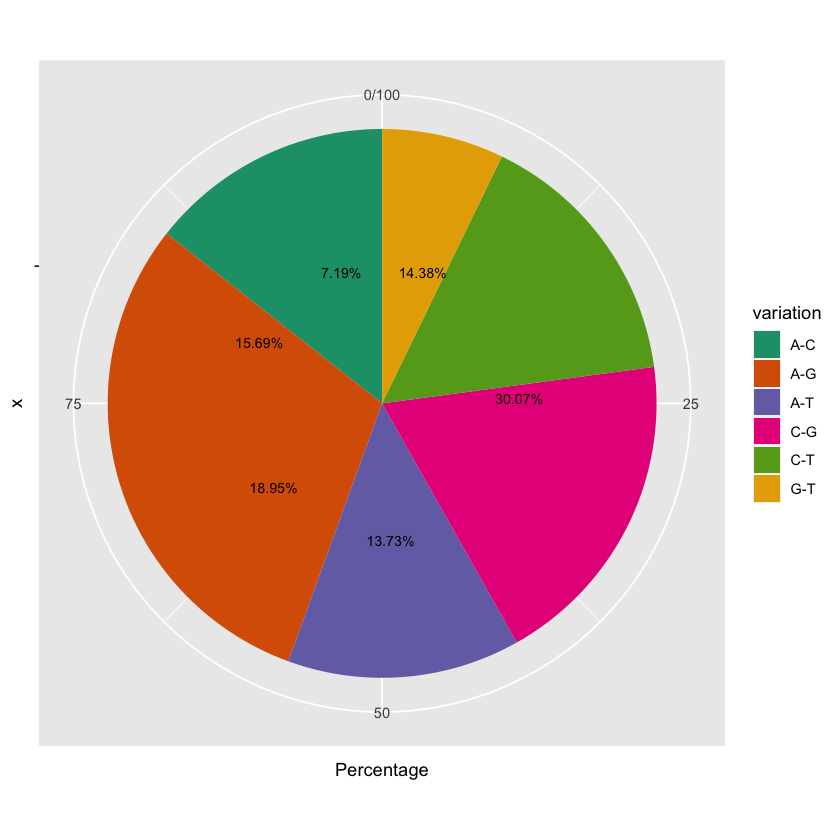

In [70]:
# pie
bp <- ggplot(spectro, aes(x="", y=Percentage, fill=variation))+
geom_bar(width = 1, stat = "identity") +
coord_polar("y", start=0) +
scale_fill_brewer(palette="Dark2") +
  geom_text(aes(y = Percentage/3 + c(0, cumsum(Percentage)[-length(Percentage)]), 
            label = percent(Percentage/100)), size=3)

bp

fig_save(bp, filename = ("figs/perc_spectro"), formats = c("pdf", "png"), width = 17, height =15, units = "cm", dpi = 320)

## (TEST) Statistical Analysis

### By sample freq

In [ ]:
dat <- data.frame(
  "SHMa_positve" = c(4, 1),
  "SHMa_negative" = c(6, 5),
  row.names = c("FL", "CLL/MBL"),
  stringsAsFactors = FALSE
)
colnames(dat) <- c("SHMa_positve", "SHMa_negative")

dat

### Expected frequencies
Remember that the Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [ ]:
chisq.test(dat)$expected

The contingency table above confirms that we should use the Fisher’s exact test instead of the Chi-square test because there is at least one cell below 5.

In [ ]:
fish <- fisher.test(dat)
fish

In [ ]:
dat_s <- data.frame(
   "shm_state" = c("SHMa_positve","SHMa_negative","SHMa_positve","SHMa_negative"),
  "n" = c(4,1,2,5),
  "group" =c("FL","FL", "CLL/MBL","CLL/MBL"),
  stringsAsFactors = FALSE
)
dat_s

In [ ]:
# Create the barplot
sample_fre <- ggplot(data=dat_s, aes(x=group, y=n, fill=shm_state)) +
  geom_bar(stat="identity")+
#  geom_text(aes(y=label_ypos, label=n), vjust=1.6, 
#            color="white", size=3.5)+
  scale_fill_brewer(palette="Paired")+
  theme_minimal()

sample_fre

fig_save(sample_fre, filename = ("figs/sample_freq"), formats = c("pdf", "png"), width = 10, height =12, units = "cm", dpi = 320)

## By cell freq

In [ ]:
#summ.cllmbl <- read.csv("output/summary_CLL_MBL.csv") %>% select(-name) %>% rename("case"="subject","subject"="case", "group"="chain", "total_cell"="Total_cell") %>% mutate(diag="MBL")

In [ ]:
summary.all <- summary %>% mutate(diag="FL") %>% bind_rows(summ.cllmbl)
summary.all

In [ ]:
group_by(summary.all, diag) %>%
  summarise(
    count = n(),
    mean = mean(Percentage, na.rm = TRUE),
    sd = sd(Percentage, na.rm = TRUE)
  )

In [ ]:
cell_fre <- ggboxplot(summary.all, x = "diag", y = "Percentage", 
          color = "diag", palette = c("#00AFBB", "#E7B800"),
        ylab = "Percentage of SHMa cells", xlab = "Diagnostic")

cell_fre

fig_save(cell_fre, filename = ("figs/cell_freq"), formats = c("pdf", "png"), width = 10, height =12, units = "cm", dpi = 320)

In [ ]:
# Shapiro-Wilk normality test for Men's weights
with(summary.all, shapiro.test(Percentage[diag == "FL"]))# p = 1.519e-05
# Shapiro-Wilk normality test for Women's weights
#with(summary.all, shapiro.test(Percentage[diag == "MBL"])) # p = 0.6

##### res <- wilcox.test(Percentage ~ diag, data = summary.all,
                   exact = FALSE)
res

### Figure 2

In [ ]:
overview <- read.csv("input/overview_plot.csv")

In [ ]:
#define gene order for plotting
sub_order <- overview  %>% arrange(-Nu_Cells_w_events) %>% pull(Patient_id) %>% unique()
sub_order

In [ ]:
overview[overview == 0] <- NA
overview <- overview %>% mutate(Patient_id = factor(Patient_id, levels = sub_order)) 
overview

In [ ]:
overview_expre <- overview %>% select(Patient_id,chain, Pos_SHMa_AID_pos,Pos_SHMa_AID_neg,Neg_SHMa_AID_pos,Neg_SHMa_AID_neg) %>% gather(-Patient_id,-chain, key="group",value="cells") %>%
group_by(Patient_id,chain,group) %>% mutate(Percentage =cells * 100 / sum(cells))

In [ ]:
fig_2 <- ggplot(overview, aes(fill=chain, y=Nu_Cells_w_events, x=Patient_id)) + 
    geom_bar(position="dodge", stat="identity") +
    geom_text(aes(label = Nu_Total_events),
              size = 3.5, position = position_dodge(width = 1),vjust = -0.5) + #, nudge_x = 0.25  nudge_y = 0.7
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, vjust=0.5,size=8)) +
    scale_fill_brewer(palette="Paired") +
    scale_x_discrete(name ="Patients") +
    scale_y_continuous(name ="Number of cells") 
     

fig_2

fig_save(fig_2, filename = paste0("figs/overview",name), formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [ ]:
overview_expre

In [ ]:
fig_2b <- ggplot(overview_expre, aes(fill=group, y=Percentage, x=Patient_id)) + 
    geom_bar(stat="identity") +
    theme(axis.text.x = element_text(angle = 90, vjust=0.5,size=8)) +
    facet_wrap(.~chain)
fig_2b

In [ ]:
ft2 <- ft %>% select(-class)
write.csv(ft2, "output/df_complete.csv", row.names =FALSE)

## Extract SHMss sequences for plotting of the events

In [71]:
willow_seq <- df %>% inner_join(df_summary_clonotype %>% select(subject,cell,vgene_position_aligned)) %>% mutate(id=paste0(subject,"_",cell,"_",umi,"_",vgene_position_aligned,"_",nucl)) %>% mutate(id_split=paste0(subject,"_",cell))
head(willow_seq)

Joining with `by = join_by(cell, vgene_position_aligned, subject)`


cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,experiment,id,id_split
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
CGAGCACAGGTTCCTA,ACCCTCTATG,342,G,C,GG.TC,6,TRUE,V,238,238,C,GG.TC,FR3,K1B_S10000-LC,K1B,K1B_S10000-LC_CGAGCACAGGTTCCTA_ACCCTCTATG_238_C,K1B_S10000-LC_CGAGCACAGGTTCCTA
CGAGCACAGGTTCCTA,ACTATTTTCT,342,G,G,GG.TC,5,TRUE,V,238,238,C,GG.TC,FR3,K1B_S10000-LC,K1B,K1B_S10000-LC_CGAGCACAGGTTCCTA_ACTATTTTCT_238_G,K1B_S10000-LC_CGAGCACAGGTTCCTA
CGAGCACAGGTTCCTA,CAATGTCATA,342,G,C,GG.TC,9,TRUE,V,238,238,C,GG.TC,FR3,K1B_S10000-LC,K1B,K1B_S10000-LC_CGAGCACAGGTTCCTA_CAATGTCATA_238_C,K1B_S10000-LC_CGAGCACAGGTTCCTA
CGAGCACAGGTTCCTA,CCCGTGCCTG,342,G,C,GG.TC,6,TRUE,V,238,238,C,GG.TC,FR3,K1B_S10000-LC,K1B,K1B_S10000-LC_CGAGCACAGGTTCCTA_CCCGTGCCTG_238_C,K1B_S10000-LC_CGAGCACAGGTTCCTA
CGAGCACAGGTTCCTA,CGCCCTATCC,342,G,C,GG.TC,7,TRUE,V,238,238,C,GG.TC,FR3,K1B_S10000-LC,K1B,K1B_S10000-LC_CGAGCACAGGTTCCTA_CGCCCTATCC_238_C,K1B_S10000-LC_CGAGCACAGGTTCCTA
CGAGCACAGGTTCCTA,CGGGTTTCCG,342,G,C,GG.TC,6,TRUE,V,238,238,C,GG.TC,FR3,K1B_S10000-LC,K1B,K1B_S10000-LC_CGAGCACAGGTTCCTA_CGGGTTTCCG_238_C,K1B_S10000-LC_CGAGCACAGGTTCCTA


In [73]:
df_summary %>% separate(umis, c("umi1", "umi2"), "-", convert = TRUE) %>% mutate(umis = umi1+umi2) %>% pull(umis) %>% sum()

[1] 3998

In [74]:
length(unique(willow_seq$id_split))

[1] 85

In [75]:
for (i in willow_seq$id_split) {
    df_fi <- willow_seq %>% filter(id_split == i)
    df_seq_fil <- df_seq %>% filter(cell %in% df_fi$cell & subject %in% df_fi$subject) %>% #  cell == "AAACGGGGTATTAGCC"
#                 select(umi,aligned_consensus) 
                   right_join(df_fi %>% select(subject,cell,umi,id),c("subject","cell","umi"))  %>% select(id,aligned_consensus) 
    Xfasta <- character(nrow(df_seq_fil) * 2)
    Xfasta[c(TRUE, FALSE)] <- paste0(">", df_seq_fil$id)
    Xfasta[c(FALSE, TRUE)] <- df_seq_fil$aligned_consensus
    
    writeLines(Xfasta, paste0("output/fasta_SHM_cells/K123/",i,".fasta"))
    
}

Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missing grouping variables: `vgene_position`
Adding missi

## Extract Consensus sequences for plotting of the events

In [ ]:
willow_seq <- df %>% inner_join(df_summary %>% select(subject,cell,vgene_position_aligned)) %>% mutate(id=paste0(subject,"_",cell,"_",umi,"_",position,"_",vgene_position_aligned,"_",nucl)) %>% mutate(id_split=paste0(subject,"_",cell))
head(willow_seq)

In [ ]:
df_summary %>% separate(umis, c("umi1", "umi2"), "-", convert = TRUE) %>% mutate(umis = umi1+umi2) %>% pull(umis) %>% sum()

In [ ]:
length(unique(willow_seq$id_split))

In [ ]:
for (i in willow_seq$id_split) {
    df_fi <- willow_seq %>% filter(id_split == i)
    df_seq_fil <- df_seq %>% filter(cell %in% df_fi$cell & subject %in% df_fi$subject) %>% #  cell == "AAACGGGGTATTAGCC"
#                 select(umi,aligned_consensus) 
                   right_join(df_fi %>% select(subject,cell,umi,id),c("subject","cell","umi"))  %>% select(id,consensus) 
    Xfasta <- character(nrow(df_seq_fil) * 2)
    Xfasta[c(TRUE, FALSE)] <- paste0(">", df_seq_fil$id)
    Xfasta[c(FALSE, TRUE)] <- df_seq_fil$consensus
    
    writeLines(Xfasta, paste0("output/fasta_SHM_cells/consensus",i,".fasta"))
    
}

## Extract Consensus sequences for plotting of the events: 

### Convert fasta file of consensus in df

In [5]:
dir_path <- "input/consensus_by_cell_v1/"

# Generate a list of files in the directory
fasta_files <- list.files(dir_path)

# Combine the directory path with each file name to create the full file paths
file_paths <- paste0(dir_path, fasta_files)

# Print the list of file paths
print(file_paths)

 [1] "input/consensus_by_cell_v1/K1B_S10000-HC_cons.fasta"
 [2] "input/consensus_by_cell_v1/K1B_S10000-LC_cons.fasta"
 [3] "input/consensus_by_cell_v1/K1B_S10971-HC_cons.fasta"
 [4] "input/consensus_by_cell_v1/K1B_S10971-LC_cons.fasta"
 [5] "input/consensus_by_cell_v1/K1B_S12282-HC_cons.fasta"
 [6] "input/consensus_by_cell_v1/K1B_S12282-LC_cons.fasta"
 [7] "input/consensus_by_cell_v1/K1B_S144-HC_cons.fasta"  
 [8] "input/consensus_by_cell_v1/K1B_S144-LC_cons.fasta"  
 [9] "input/consensus_by_cell_v1/K1B_S8934-HC_cons.fasta" 
[10] "input/consensus_by_cell_v1/K1B_S8934-LC_cons.fasta" 
[11] "input/consensus_by_cell_v1/K2B_S11770-HC_cons.fasta"
[12] "input/consensus_by_cell_v1/K2B_S11770-LC_cons.fasta"
[13] "input/consensus_by_cell_v1/K2B_S12118-HC_cons.fasta"
[14] "input/consensus_by_cell_v1/K2B_S12118-LC_cons.fasta"
[15] "input/consensus_by_cell_v1/K2B_S12500-HC_cons.fasta"
[16] "input/consensus_by_cell_v1/K2B_S12500-LC_cons.fasta"
[17] "input/consensus_by_cell_v1/K2B_S13530-HC_cons.fast

In [6]:
# Remove the row names
rownames(df) <- NULL

In [7]:
# Initialize empty lists to store sequence names and sequences
names_list <- list()
seqs_list <- list()

# Loop through the fasta files and extract the sequence names and sequences
for (file in file_paths) {
  sequences <- readDNAStringSet(file)
  names_list[[file]] <- names(sequences)
  seqs_list[[file]] <- as.character(sequences)
}

# Combine the sequence names and sequences into one list
names_combined <- unlist(names_list)
seqs_combined <- unlist(seqs_list)

# Create a dataframe
df <- data.frame(names_combined, seqs_combined)

# Rename the columns
names(df) <- c("id", "seq")

In [8]:
# Remove the row names
rownames(df) <- NULL

In [9]:
head(df) 

,id,seq
,<chr>,<chr>
1,K1B_S10000-HC--AAACCTGGTCCAGTAT,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCAGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTGTATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
2,K1B_S10000-HC--AAACGGGCATCACGTA,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCAGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTGTATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAATTCCCCGTCGGATACGAGCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
3,K1B_S10000-HC--AAACGGGAGTCGATAA,NNNNNNNNNNNNNNNNNNNNNNNNNNNNATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGATTCATGGAGAAATAGAGAGACTGAGTGTGAGTGAATATGAGTGAGAAAAACTGGACTTGTGTGGCAATCTCTGATAACGATGTCTTTCTACTTGCAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCAGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTGTATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCNN
4,K1B_S10000-HC--AACTGGTTCTAACTGG,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCAGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAATTCCCCGTCGGATACGAGCANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
5,K1B_S10000-HC--AAAGATGAGGCTCAGA,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGGTGTTTCCATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAAC

In [10]:
df %>% pull(id) %>% unique() %>% str()

 chr [1:80613] "K1B_S10000-HC--AAACCTGGTCCAGTAT" ...


In [11]:
df_all <- read.csv("output/df_summary_K12345678.csv") %>% mutate(id = paste0(subject,"--",cell)) 

In [12]:
cell_chain <- df_all %>% pull(id) %>% unique()

In [13]:
#write.csv(cell_chain, "cell_positives.csv")

In [14]:
head(cell_chain)

[1] "K1B_S10000-LC--TTAGGCAGTCGAACAG" "K1B_S10000-LC--CTAGCCTCAATCACAC"
[3] "K1B_S10000-LC--ACTTTCACATTGTGCA" "K1B_S144-HC--CTCGAGGCAATGACCT"  
[5] "K1B_S144-HC--GTCACAACAACGATCT"   "K1B_S144-LC--TTTCCTCCACTTAAGC"

In [15]:
df_filter <- df %>%
             filter(id %in% cell_chain)

In [16]:
df_filter 

id,seq
<chr>,<chr>
K1B_S10000-LC--ACTTTCACATTGTGCA,TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCACTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTGTGCTGACGCAGCCGCCCTCAGTGTCTGGGGCCCCAGGGCAAAGGGTCACCATCTCGTACACTGGGAACAGCTCCAACATCGGGGCAGGTTTTGATGTACACTGGTACCAGCAGTTTCCAGGAACAGCCCCCAAACTCCTCATCTATGGTGACTCCAATCGGCCCTCAGGGGTCCCTGGCCGATTCTCTGGCTCCAAGTCTGGCACCTCTGCCTCCCTGGCCATCTCTGGGCTCCAGGCTGAGGATGAGGCTGATTATTACTGCCAGTCCTATGTCANNNNNNNNNNNNNNNNNNNNNNNNNNAATGGGGTGTTCGGCGGAGGGACGAAGTTGACCGTCCTCGGNCAGCCCANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
K1B_S10000-LC--CTAGCCTCAATCACAC,TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCACTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTGTGCTGACGCAGCCGCCCTCAGTGTCTGGGGCCCCAGGGCAAAGGGTCACCATNTCGTGCACTGGGAACAGCTCCAACATCGGGGCAGGTTTTGATGTACACTGGTACCAGCAGTTTCCAGGAACAGCCCCCAAACTCCTCATNTATGGTGACTCCAATCGGCCCTCAGGGGTCCCTGGCCGATTCTCTGGCTCCAAGTCTGGCACCTCTGCCTCCCTGGCCATCTCTGGGCTCCAGGCTGAGGATGAGGCTGATTATTACTGCCAGTCCTATGTCACCAGGCAGTCCTATGGCAGCAGCCTNAATGGGGNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
K1B_S10000-LC--TTAGGCAGTCGAACAG,TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCAGTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTGTTCTGACGCAGCCGCCCTCAGTGTCTGGGGCCCCAGGGCAAAGGGTCACCATCTCGTGCACTGGGAACAGCTCCAACATCGGGGCAGGTTTTGATGTACACTGGTACCAGCAGTTTCCAGGAACAGCCCCCAAACTCCTCATCTATGGTGACTCCAATCGGCCCTCAGGGGTCCCTGGCCGATTCTCTGGCTCCAAGTCTGGCACCTCTGCCTCCCTGGCCATCTCTGGGCTCCAGGCTGAGGATGAGGCTGATTATTACTGCCAGTCCTATGTCACCAGGCAGTCCTATGGCAGCAGCCTAAATGNGGTGTTCGGCGGAGGGACGANNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
K1B_S144-HC--CTCGAGGCAATGACCT,TGGGAGAGGAGCCCAGCACTAGAAGTCGGCGGTGTTTCCATTCGGTGATCAGCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAGCTGGGTTTTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGAGCAACTGGTGGAGTCTGGGGGAGGCGTGATCCAGCCTGGGAGGTCCCTGAGACTCTCCTGTGCAGCCTCTCGATTTATCTTCAGTAACTTTGGCATGCACTGGGTCCGCCAGGCACCAGGCAAGGGGCTGGAGTGGGTGGCAAATATATCATATGATGGAACTAATAAATACTATGGAGACTTCGTGAAGGGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGGTGTATCTGCAAATGAACAGCCTGAGACCTGATGACACGGCTGTATATTTCTGTGCGAGGGGGCGTGGGGCGTTCGCAGTGATGCGAGGCGGCGACTACAACGGTATGGACGTCTGGGGCCAAGGGACCACGGTCACCGTCTCGTCAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAATTCCCCGTCGGATACGAGNN
K1B_S144-HC--GTCACAACAACGATCT,CTGGGAGAGGAGCCCAGCACTAGAAGTCGGCGGTGTTTCCATTCGGTGATCAGCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAGCTGGGTTTTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGAGCAACTGGTGGAGTCTGGGGGAGGCGTGATCCAGCCTGGGAGGTCCCTGAGACTCTCCTGTGCAGCCTCTCGATTTATCTTCAGTAACTTTGGCATGCACTGGGTCCGCCAGGCACCAGGCAAGGGNCTGGAGTGGGTGGCAAATATATCATATGATGGAANTAATAAATACTATGGAGACTTCGTGAAGGGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGGTGTATCTGCAAATGAACAGCCTGAGACCTGATGACACGGCTGTATATTTCTGTGCGAGGGGGCGTGGGGCGTTCGCAGTGATGCGAGGCGGCGACTACAACGGTATGGACGTCTGGGGCCAAGGGACCACGGTCACCGTCTCGTCAGGGAGTGCATCCGCCCCAACCCTTTTCCCCCTCGTCTCCTGTGAGAATTCCCCGTCGGATACGNNNN
K1B_S144-LC--ACGCAGCAGCAGGCTA,TTTCTTATATGGNNGGAATCAGTCCCACTCAGGACACAGCATGGACATGAGGGTCCCCGCTCAGCTCCTGGGGCTCCTGCTGCTCTGGTTCCCAGGTGCCAGGTGTGACATCCAGATGACCCAGTCTCCATCCTCCCTGTCTGCATCTGTAGGAGACAGCGTCACCATCACTTGCCGGGCAAGTCAGGGCATTAGAAATGATTTAGGCTGGTTTCAGCAGAAACCAGGGAAAGCCCCTAAGCGCCTGATCTATGCTGCATCCAGTTTGCAAAGTGGGGTCCCATCAAGGTTCAGCGGCTATGGATCTGGGACAGAGTTCACTCTCACAATCAGCAGCCTGCAGCCTGAAGATTTTGCAACTTATTT

In [19]:
write.csv(df_filter, "output/fasta_SHM_cells/consensus_cell_positives.csv")